<a href="https://colab.research.google.com/github/maciejczek3324/pyton/blob/master/collab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [12]:
x=np.linspace(-6,6,100,dtype=np.float32)
y=np.linspace(-6,6,100,dtype=np.float32)
X, Y = np.meshgrid(x,y)

Z=np.sin(X)*np.cos(Y)+X*Y**2-np.exp(-X)
Z=Z+np.random.normal(scale=0.5, size=Z.shape)

X=X.reshape(-1,1).astype(np.float32)
Y=Y.reshape(-1,1).astype(np.float32)
Z=Z.reshape(-1,1).astype(np.float32)

input_data=np.hstack((X,Y)).astype(np.float32)

In [9]:
model = keras.Sequential([
    layers.Dense(64,activation='relu',input_shape=(2,)),
    layers.Dense(32,activation='tanh'),
    layers.Dense(16,activation='relu'),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.fit(input_data, Z, epochs=200, batch_size=64, verbose=0)

In [14]:
x_range=np.linspace(-6,6,50,dtype=np.float32)
y_range=np.linspace(-6,6,50,dtype=np.float32)
X_plot, Y_plot = np.meshgrid(x_range,y_range)
input_plot=np.hstack((X_plot.reshape(-1,1),Y_plot.reshape(-1,1)))

Z_pred=model.predict(input_plot)
Z_pred=Z_pred.reshape(X_plot.shape)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/tmp/ipykernel_8671/441313074.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax2.scatter(X_plot,Y_plot,Z_pred, cmap='viridis')


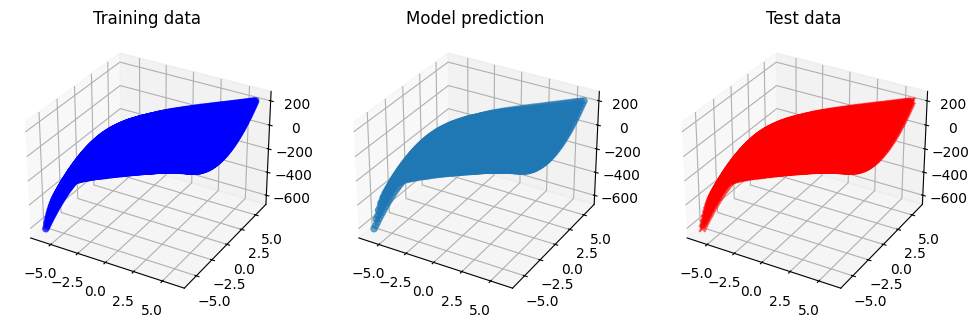

In [21]:
fig=plt.figure(figsize=(12,4))

ax1=fig.add_subplot(131,projection='3d')
ax1.scatter(X,Y,Z,c='b',marker='o',label='Training data')
ax1.set_title('Training data')

ax2=fig.add_subplot(132,projection='3d')
ax2.scatter(X_plot,Y_plot,Z_pred, cmap='viridis')
ax2.set_title('Model prediction')

ax3=fig.add_subplot(133,projection='3d')
ax3.scatter(X,Y,Z,c='r',marker='x',label='Test data')
ax3.set_title('Test data')

plt.show()